<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET
Total samples : 20000
Features      : 8
Training      : 16000
Testing       : 4000
Class 0       : 10243
Class 1       : 9757


TRAINING GRADIENT DESCENT
Iterations: 2000
Training time: 1.759586 seconds


TRAINING NEWTON'S METHOD / IRLS
Iterations: 8
Training time: 0.023863 seconds


GRADIENT DESCENT - TEST RESULTS
True Positive  (TP): 1669
False Positive (FP): 261
True Negative  (TN): 1813
False Negative (FN): 257

Accuracy : 0.870500
Precision: 0.864767
Recall   : 0.866563
F1 Score : 0.865664
Log Loss : 0.288647


NEWTON'S METHOD / IRLS - TEST RESULTS
True Positive  (TP): 1669
False Positive (FP): 261
True Negative  (TN): 1813
False Negative (FN): 257

Accuracy : 0.870500
Precision: 0.864767
Recall   : 0.866563
F1 Score : 0.865664
Log Loss : 0.288689


GRADIENT DESCENT vs NEWTON / IRLS
Metric                       Gradient Descent            Newton / IRLS
------------------------------------------------------------------------------------------
Iterations                     

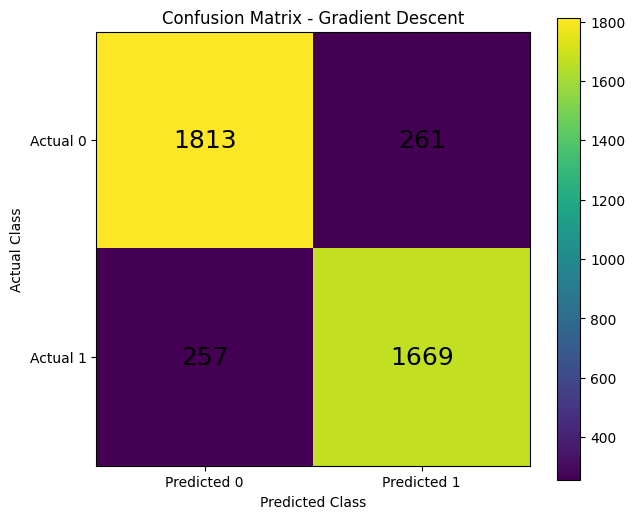

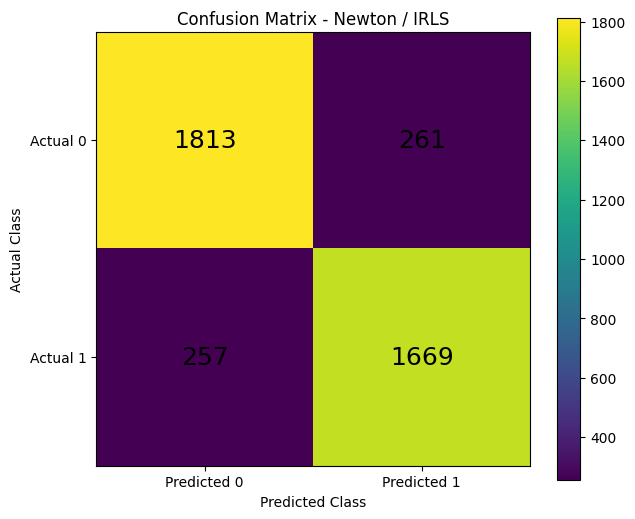

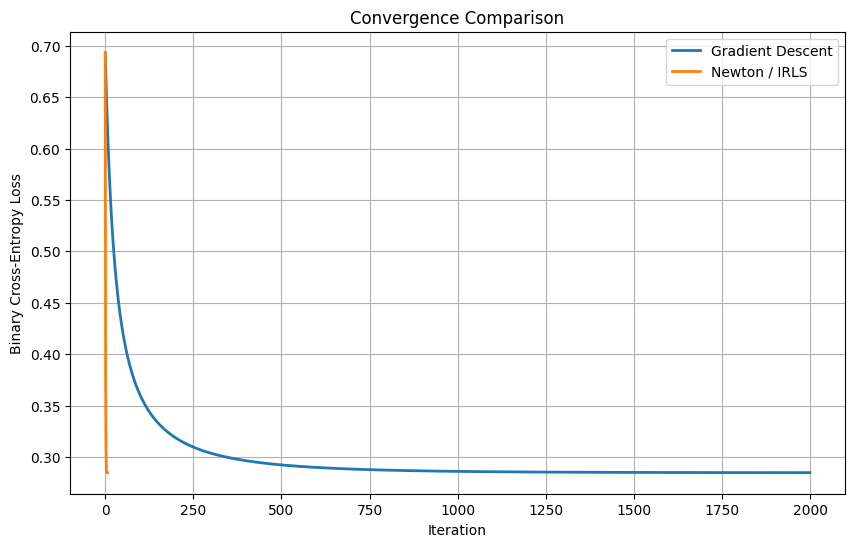

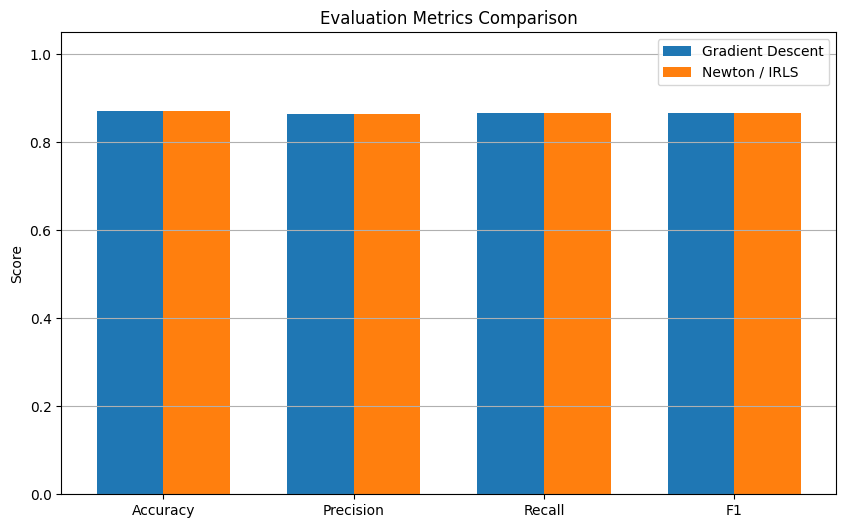



LEARNED PARAMETERS

Gradient Descent Weights:
[ 1.78142749 -2.16234562  1.32926541 -1.51951511  0.89339518 -1.0875738
  1.29951265 -0.74088517]

Gradient Descent Bias:
-0.17538978679273573

Newton / IRLS Weights:
[ 1.82532719 -2.21632874  1.36178221 -1.55756425  0.91554727 -1.11507131
  1.33212958 -0.75947262]

Newton / IRLS Bias:
-0.1803386697251656


PARAMETER DIFFERENCE
Weight difference: 0.10001313295747673
Bias difference: 0.004948882932429871


In [2]:
# ============================================================
# LOGISTIC REGRESSION FROM SCRATCH
#
# TWO OPTIMIZATION METHODS:
#
# 1. Gradient Descent
# 2. Newton's Method / IRLS
#
# Comparison:
#   - Confusion Matrix
#   - Accuracy
#   - Precision
#   - Recall
#   - F1 Score
#   - TP / FP / TN / FN
#   - Log Loss
#   - Number of Iterations
#   - Training Time
#
# Libraries:
#   NumPy
#   Matplotlib
#
# NO SKLEARN
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. CREATE A LARGE DATASET
# ============================================================

np.random.seed(42)

n_samples = 20000
n_features = 8


# ------------------------------------------------------------
# Generate feature matrix
# ------------------------------------------------------------

X = np.random.randn(
    n_samples,
    n_features
)


# ------------------------------------------------------------
# True parameters used only for generating synthetic data
# ------------------------------------------------------------

true_weights = np.array([
    1.8,
    -2.2,
    1.4,
    -1.6,
    0.9,
    -1.1,
    1.3,
    -0.8
])


true_bias = -0.2


# ------------------------------------------------------------
# Generate linear score
#
# z = Xw + b
# ------------------------------------------------------------

z_true = (
    X @ true_weights
    +
    true_bias
)


# ------------------------------------------------------------
# Generate probabilities
#
# p = sigmoid(z)
# ------------------------------------------------------------

def sigmoid(z):

    z = np.clip(
        z,
        -500,
        500
    )

    return 1 / (
        1 + np.exp(-z)
    )


probabilities_true = sigmoid(
    z_true
)


# ------------------------------------------------------------
# Generate binary labels
# ------------------------------------------------------------

y = (
    np.random.rand(n_samples)
    <
    probabilities_true
).astype(int)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

indices = np.random.permutation(
    n_samples
)


train_size = int(
    0.8 * n_samples
)


train_indices = indices[
    :train_size
]

test_indices = indices[
    train_size:
]


X_train = X[
    train_indices
]

y_train = y[
    train_indices
]


X_test = X[
    test_indices
]

y_test = y[
    test_indices
]


print("=" * 70)
print("DATASET")
print("=" * 70)

print(
    "Total samples :",
    n_samples
)

print(
    "Features      :",
    n_features
)

print(
    "Training      :",
    len(X_train)
)

print(
    "Testing       :",
    len(X_test)
)

print(
    "Class 0       :",
    np.sum(y == 0)
)

print(
    "Class 1       :",
    np.sum(y == 1)
)


# ============================================================
# 3. LOGISTIC REGRESSION USING GRADIENT DESCENT
# ============================================================

class LogisticRegressionGD:

    def __init__(
        self,
        learning_rate=0.1,
        n_iterations=1000,
        tolerance=1e-8
    ):

        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance

        self.coef_ = None
        self.intercept_ = None

        self.loss_history_ = []

        self.n_iter_ = 0
        self.training_time_ = 0


    # ========================================================
    # SIGMOID
    # ========================================================

    def _sigmoid(self, z):

        z = np.clip(
            z,
            -500,
            500
        )

        return 1 / (
            1 + np.exp(-z)
        )


    # ========================================================
    # BINARY CROSS ENTROPY
    # ========================================================

    def _compute_loss(
        self,
        y,
        probability
    ):

        epsilon = 1e-15

        probability = np.clip(
            probability,
            epsilon,
            1 - epsilon
        )

        loss = -np.mean(
            y * np.log(probability)
            +
            (1 - y)
            *
            np.log(1 - probability)
        )

        return loss


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y
    ):

        start_time = time.perf_counter()


        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )


        n_samples, n_features = X.shape


        # ----------------------------------------------------
        # Initialize parameters
        # ----------------------------------------------------

        self.coef_ = np.zeros(
            n_features
        )

        self.intercept_ = 0.0

        self.loss_history_ = []


        # ====================================================
        # GRADIENT DESCENT
        # ====================================================

        for iteration in range(
            self.n_iterations
        ):


            # ------------------------------------------------
            # z = Xw + b
            # ------------------------------------------------

            z = (
                X @ self.coef_
                +
                self.intercept_
            )


            # ------------------------------------------------
            # p = sigmoid(z)
            # ------------------------------------------------

            probability = self._sigmoid(
                z
            )


            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            loss = self._compute_loss(
                y,
                probability
            )


            self.loss_history_.append(
                loss
            )


            # ------------------------------------------------
            # Error
            #
            # error = p - y
            # ------------------------------------------------

            error = (
                probability - y
            )


            # ------------------------------------------------
            # Gradient of weights
            #
            # dw = Xᵀ(p-y) / n
            # ------------------------------------------------

            dw = (
                X.T @ error
            ) / n_samples


            # ------------------------------------------------
            # Gradient of bias
            #
            # db = mean(p-y)
            # ------------------------------------------------

            db = np.mean(
                error
            )


            # ------------------------------------------------
            # Update weights
            # ------------------------------------------------

            self.coef_ -= (
                self.learning_rate
                *
                dw
            )


            # ------------------------------------------------
            # Update bias
            # ------------------------------------------------

            self.intercept_ -= (
                self.learning_rate
                *
                db
            )


            # ------------------------------------------------
            # Convergence check
            # ------------------------------------------------

            if (
                np.linalg.norm(dw)
                <
                self.tolerance
            ):

                self.n_iter_ = (
                    iteration + 1
                )

                break


        else:

            self.n_iter_ = (
                self.n_iterations
            )


        self.training_time_ = (
            time.perf_counter()
            -
            start_time
        )


        return self


    # ========================================================
    # PREDICT PROBABILITY
    # ========================================================

    def predict_proba(
        self,
        X
    ):

        z = (
            X @ self.coef_
            +
            self.intercept_
        )

        return self._sigmoid(
            z
        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        probability = (
            self.predict_proba(X)
        )

        return (
            probability >= 0.5
        ).astype(int)


# ============================================================
# 4. LOGISTIC REGRESSION USING NEWTON'S METHOD / IRLS
# ============================================================

class LogisticRegressionNewton:

    def __init__(
        self,
        n_iterations=100,
        tolerance=1e-8
    ):

        self.n_iterations = n_iterations
        self.tolerance = tolerance

        self.coef_ = None
        self.intercept_ = None

        self.loss_history_ = []

        self.n_iter_ = 0
        self.training_time_ = 0


    # ========================================================
    # SIGMOID
    # ========================================================

    def _sigmoid(self, z):

        z = np.clip(
            z,
            -500,
            500
        )

        return 1 / (
            1 + np.exp(-z)
        )


    # ========================================================
    # BINARY CROSS ENTROPY
    # ========================================================

    def _compute_loss(
        self,
        y,
        probability
    ):

        epsilon = 1e-15

        probability = np.clip(
            probability,
            epsilon,
            1 - epsilon
        )

        loss = -np.mean(
            y * np.log(probability)
            +
            (1 - y)
            *
            np.log(1 - probability)
        )

        return loss


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y
    ):

        start_time = time.perf_counter()


        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )


        n_samples, n_features = X.shape


        # ----------------------------------------------------
        # Add column of ones for the intercept
        #
        # X_augmented =
        #
        # [1 x1 x2 x3 ...]
        # [1 x1 x2 x3 ...]
        # ...
        #
        # This allows:
        #
        # z = X_augmented @ theta
        #
        # where theta contains:
        #
        # [bias, weights...]
        # ----------------------------------------------------

        X_augmented = np.column_stack(
            (
                np.ones(n_samples),
                X
            )
        )


        # ----------------------------------------------------
        # Initialize parameter vector
        #
        # theta =
        #
        # [b, w1, w2, ..., wd]
        # ----------------------------------------------------

        theta = np.zeros(
            n_features + 1
        )


        self.loss_history_ = []


        # ====================================================
        # NEWTON'S METHOD / IRLS
        # ====================================================

        for iteration in range(
            self.n_iterations
        ):


            # ------------------------------------------------
            # Step 1:
            #
            # z = Xtheta
            # ------------------------------------------------

            z = (
                X_augmented @ theta
            )


            # ------------------------------------------------
            # Step 2:
            #
            # p = sigmoid(z)
            # ------------------------------------------------

            probability = (
                self._sigmoid(z)
            )


            # ------------------------------------------------
            # Step 3:
            #
            # Calculate loss
            # ------------------------------------------------

            loss = self._compute_loss(
                y,
                probability
            )


            self.loss_history_.append(
                loss
            )


            # ------------------------------------------------
            # Step 4:
            #
            # Gradient
            #
            # g = Xᵀ(p-y)
            # ------------------------------------------------

            gradient = (
                X_augmented.T
                @
                (
                    probability - y
                )
            )


            # ------------------------------------------------
            # Step 5:
            #
            # Hessian
            #
            # H = XᵀWX
            #
            # W is diagonal:
            #
            # p(1-p)
            # ------------------------------------------------

            weights = (
                probability
                *
                (
                    1 - probability
                )
            )


            # ------------------------------------------------
            # Efficient Hessian construction
            #
            # Instead of explicitly creating:
            #
            # W = diag(p(1-p))
            #
            # we multiply each row of X by weights.
            # ------------------------------------------------

            X_weighted = (
                X_augmented
                *
                weights[:, np.newaxis]
            )


            hessian = (
                X_augmented.T
                @
                X_weighted
            )


            # ------------------------------------------------
            # Step 6:
            #
            # Newton update:
            #
            # theta_new =
            # theta_old - H⁻¹g
            #
            # We DO NOT explicitly calculate H⁻¹.
            #
            # Instead solve:
            #
            # H delta = g
            #
            # which is numerically better.
            # ------------------------------------------------

            try:

                delta = np.linalg.solve(
                    hessian,
                    gradient
                )

            except np.linalg.LinAlgError:

                # Small diagonal regularization
                # only for numerical stability.

                regularization = (
                    1e-8
                    *
                    np.eye(
                        n_features + 1
                    )
                )

                delta = np.linalg.solve(
                    hessian
                    +
                    regularization,
                    gradient
                )


            # ------------------------------------------------
            # Step 7:
            #
            # Update parameters
            # ------------------------------------------------

            theta -= delta


            # ------------------------------------------------
            # Convergence
            # ------------------------------------------------

            if (
                np.linalg.norm(delta)
                <
                self.tolerance
            ):

                self.n_iter_ = (
                    iteration + 1
                )

                break


        else:

            self.n_iter_ = (
                self.n_iterations
            )


        # ----------------------------------------------------
        # Separate bias and weights
        # ----------------------------------------------------

        self.intercept_ = theta[0]

        self.coef_ = theta[1:]


        self.training_time_ = (
            time.perf_counter()
            -
            start_time
        )


        return self


    # ========================================================
    # PREDICT PROBABILITY
    # ========================================================

    def predict_proba(
        self,
        X
    ):

        z = (
            X @ self.coef_
            +
            self.intercept_
        )

        return self._sigmoid(
            z
        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        probability = (
            self.predict_proba(X)
        )

        return (
            probability >= 0.5
        ).astype(int)


# ============================================================
# 5. CREATE BOTH MODELS
# ============================================================

model_gd = LogisticRegressionGD(
    learning_rate=0.1,
    n_iterations=2000,
    tolerance=1e-8
)


model_newton = LogisticRegressionNewton(
    n_iterations=100,
    tolerance=1e-8
)


# ============================================================
# 6. TRAIN GRADIENT DESCENT
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING GRADIENT DESCENT")
print("=" * 70)

model_gd.fit(
    X_train,
    y_train
)

print(
    "Iterations:",
    model_gd.n_iter_
)

print(
    "Training time:",
    f"{model_gd.training_time_:.6f}",
    "seconds"
)


# ============================================================
# 7. TRAIN NEWTON / IRLS
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING NEWTON'S METHOD / IRLS")
print("=" * 70)

model_newton.fit(
    X_train,
    y_train
)

print(
    "Iterations:",
    model_newton.n_iter_
)

print(
    "Training time:",
    f"{model_newton.training_time_:.6f}",
    "seconds"
)


# ============================================================
# 8. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X,
    y
):

    predictions = (
        model.predict(X)
    )


    probabilities = (
        model.predict_proba(X)
    )


    # --------------------------------------------------------
    # Confusion Matrix Components
    # --------------------------------------------------------

    TP = np.sum(
        (y == 1)
        &
        (predictions == 1)
    )


    FP = np.sum(
        (y == 0)
        &
        (predictions == 1)
    )


    TN = np.sum(
        (y == 0)
        &
        (predictions == 0)
    )


    FN = np.sum(
        (y == 1)
        &
        (predictions == 0)
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = (
        (TP + TN)
        /
        (TP + TN + FP + FN)
    )


    # --------------------------------------------------------
    # Precision
    #
    # TP / (TP + FP)
    # --------------------------------------------------------

    if TP + FP == 0:

        precision = 0.0

    else:

        precision = (
            TP
            /
            (TP + FP)
        )


    # --------------------------------------------------------
    # Recall
    #
    # TP / (TP + FN)
    # --------------------------------------------------------

    if TP + FN == 0:

        recall = 0.0

    else:

        recall = (
            TP
            /
            (TP + FN)
        )


    # --------------------------------------------------------
    # F1 Score
    #
    # 2 * Precision * Recall
    # -----------------------
    # Precision + Recall
    # --------------------------------------------------------

    if precision + recall == 0:

        f1 = 0.0

    else:

        f1 = (
            2
            *
            precision
            *
            recall
            /
            (
                precision
                +
                recall
            )
        )


    # --------------------------------------------------------
    # Log Loss
    # --------------------------------------------------------

    epsilon = 1e-15

    probabilities = np.clip(
        probabilities,
        epsilon,
        1 - epsilon
    )


    log_loss = -np.mean(
        y * np.log(probabilities)
        +
        (1 - y)
        *
        np.log(1 - probabilities)
    )


    return {
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Log Loss": log_loss
    }


# ============================================================
# 9. EVALUATE BOTH MODELS
# ============================================================

gd_results = evaluate_model(
    model_gd,
    X_test,
    y_test
)


newton_results = evaluate_model(
    model_newton,
    X_test,
    y_test
)


# ============================================================
# 10. PRINT GRADIENT DESCENT RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("GRADIENT DESCENT - TEST RESULTS")
print("=" * 70)

print(
    "True Positive  (TP):",
    gd_results["TP"]
)

print(
    "False Positive (FP):",
    gd_results["FP"]
)

print(
    "True Negative  (TN):",
    gd_results["TN"]
)

print(
    "False Negative (FN):",
    gd_results["FN"]
)

print()

print(
    f"Accuracy : {gd_results['Accuracy']:.6f}"
)

print(
    f"Precision: {gd_results['Precision']:.6f}"
)

print(
    f"Recall   : {gd_results['Recall']:.6f}"
)

print(
    f"F1 Score : {gd_results['F1']:.6f}"
)

print(
    f"Log Loss : {gd_results['Log Loss']:.6f}"
)


# ============================================================
# 11. PRINT NEWTON / IRLS RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("NEWTON'S METHOD / IRLS - TEST RESULTS")
print("=" * 70)

print(
    "True Positive  (TP):",
    newton_results["TP"]
)

print(
    "False Positive (FP):",
    newton_results["FP"]
)

print(
    "True Negative  (TN):",
    newton_results["TN"]
)

print(
    "False Negative (FN):",
    newton_results["FN"]
)

print()

print(
    f"Accuracy : {newton_results['Accuracy']:.6f}"
)

print(
    f"Precision: {newton_results['Precision']:.6f}"
)

print(
    f"Recall   : {newton_results['Recall']:.6f}"
)

print(
    f"F1 Score : {newton_results['F1']:.6f}"
)

print(
    f"Log Loss : {newton_results['Log Loss']:.6f}"
)


# ============================================================
# 12. SIDE-BY-SIDE COMPARISON
# ============================================================

print("\n")
print("=" * 90)
print("GRADIENT DESCENT vs NEWTON / IRLS")
print("=" * 90)

print(
    f"{'Metric':<20}"
    f"{'Gradient Descent':>25}"
    f"{'Newton / IRLS':>25}"
)

print("-" * 90)

print(
    f"{'Iterations':<20}"
    f"{model_gd.n_iter_:>25}"
    f"{model_newton.n_iter_:>25}"
)

print(
    f"{'Training Time':<20}"
    f"{model_gd.training_time_:>25.6f}"
    f"{model_newton.training_time_:>25.6f}"
)

print(
    f"{'Accuracy':<20}"
    f"{gd_results['Accuracy']:>25.6f}"
    f"{newton_results['Accuracy']:>25.6f}"
)

print(
    f"{'Precision':<20}"
    f"{gd_results['Precision']:>25.6f}"
    f"{newton_results['Precision']:>25.6f}"
)

print(
    f"{'Recall':<20}"
    f"{gd_results['Recall']:>25.6f}"
    f"{newton_results['Recall']:>25.6f}"
)

print(
    f"{'F1 Score':<20}"
    f"{gd_results['F1']:>25.6f}"
    f"{newton_results['F1']:>25.6f}"
)

print(
    f"{'Log Loss':<20}"
    f"{gd_results['Log Loss']:>25.6f}"
    f"{newton_results['Log Loss']:>25.6f}"
)

print(
    f"{'TP':<20}"
    f"{gd_results['TP']:>25}"
    f"{newton_results['TP']:>25}"
)

print(
    f"{'FP':<20}"
    f"{gd_results['FP']:>25}"
    f"{newton_results['FP']:>25}"
)

print(
    f"{'TN':<20}"
    f"{gd_results['TN']:>25}"
    f"{newton_results['TN']:>25}"
)

print(
    f"{'FN':<20}"
    f"{gd_results['FN']:>25}"
    f"{newton_results['FN']:>25}"
)


# ============================================================
# 13. CONFUSION MATRIX - GRADIENT DESCENT
# ============================================================

gd_cm = np.array([
    [
        gd_results["TN"],
        gd_results["FP"]
    ],
    [
        gd_results["FN"],
        gd_results["TP"]
    ]
])


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    gd_cm
)

plt.colorbar()

plt.xticks(
    [0, 1],
    [
        "Predicted 0",
        "Predicted 1"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Actual 0",
        "Actual 1"
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            gd_cm[i, j],
            ha="center",
            va="center",
            fontsize=18
        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix - Gradient Descent"
)

plt.show()


# ============================================================
# 14. CONFUSION MATRIX - NEWTON / IRLS
# ============================================================

newton_cm = np.array([
    [
        newton_results["TN"],
        newton_results["FP"]
    ],
    [
        newton_results["FN"],
        newton_results["TP"]
    ]
])


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    newton_cm
)

plt.colorbar()

plt.xticks(
    [0, 1],
    [
        "Predicted 0",
        "Predicted 1"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Actual 0",
        "Actual 1"
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            newton_cm[i, j],
            ha="center",
            va="center",
            fontsize=18
        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix - Newton / IRLS"
)

plt.show()


# ============================================================
# 15. LOSS COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    model_gd.loss_history_,
    label="Gradient Descent",
    linewidth=2
)


plt.plot(
    model_newton.loss_history_,
    label="Newton / IRLS",
    linewidth=2
)


plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Binary Cross-Entropy Loss"
)

plt.title(
    "Convergence Comparison"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 16. METRICS COMPARISON
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


gd_metric_values = [
    gd_results["Accuracy"],
    gd_results["Precision"],
    gd_results["Recall"],
    gd_results["F1"]
]


newton_metric_values = [
    newton_results["Accuracy"],
    newton_results["Precision"],
    newton_results["Recall"],
    newton_results["F1"]
]


x_positions = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    x_positions - width / 2,
    gd_metric_values,
    width,
    label="Gradient Descent"
)


plt.bar(
    x_positions + width / 2,
    newton_metric_values,
    width,
    label="Newton / IRLS"
)


plt.xticks(
    x_positions,
    metric_names
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "Evaluation Metrics Comparison"
)

plt.grid(
    axis="y"
)

plt.legend()

plt.show()


# ============================================================
# 17. FINAL PARAMETER COMPARISON
# ============================================================

print("\n")
print("=" * 70)
print("LEARNED PARAMETERS")
print("=" * 70)

print(
    "\nGradient Descent Weights:"
)

print(
    model_gd.coef_
)

print(
    "\nGradient Descent Bias:"
)

print(
    model_gd.intercept_
)


print(
    "\nNewton / IRLS Weights:"
)

print(
    model_newton.coef_
)

print(
    "\nNewton / IRLS Bias:"
)

print(
    model_newton.intercept_
)


# ============================================================
# 18. PARAMETER DIFFERENCE
# ============================================================

weight_difference = np.linalg.norm(
    model_gd.coef_
    -
    model_newton.coef_
)


bias_difference = abs(
    model_gd.intercept_
    -
    model_newton.intercept_
)


print("\n")
print("=" * 70)
print("PARAMETER DIFFERENCE")
print("=" * 70)

print(
    "Weight difference:",
    weight_difference
)

print(
    "Bias difference:",
    bias_difference
)